In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
orders = pd.read_excel("data/orders.xlsx")
products = pd.read_excel("data/products.xlsx")

In [5]:
orders.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [6]:
products.head()

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


# 1 Task

Самая ходовая товарная группа
По какой категории товаров продано больше всего позиций?

Подкрепите свой ответ таблицей, в которой рассчитано количество проданных штук товара в каждой товарной категории.
Дополнительно постройте на основании этой таблицы barchart.
Проверьте, чтобы все подписи на вашем графике выглядели читаемо и понятно. Этот график должен быть сходу понятен стороннему наблюдателю.

In [7]:
df1 = orders.merge(products, on="product_id", how="left")

df1.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [8]:
res1 = df1.groupby("level1")["quantity"].sum().sort_values(ascending=False)

res1

level1
Безалкогольные напитки          534
Молочная продукция              483
Свежие овощи                    262
Кулинария                       250
Бакалея                         239
Хлеб и хлебобулочные изделия    218
Снэки                           212
Свежие фрукты                   184
Замороженная продукция          175
Кондитерские изделия            138
Мучные кондитерские изделия     124
Сыры                            114
Продукция для животных          113
Мясная гастрономия              112
Детское питание                  96
Птица                            90
Гигиена                          77
Консервированные продукты        74
Рыбная гастрономия               44
Яичные товары                    40
Чай                              40
Мясо                             29
Уход                             24
Бытовая химия                    23
Кофе, какао                      21
Рыба                              8
Детство (Гигиена и Уход)          6
Специальное питание  

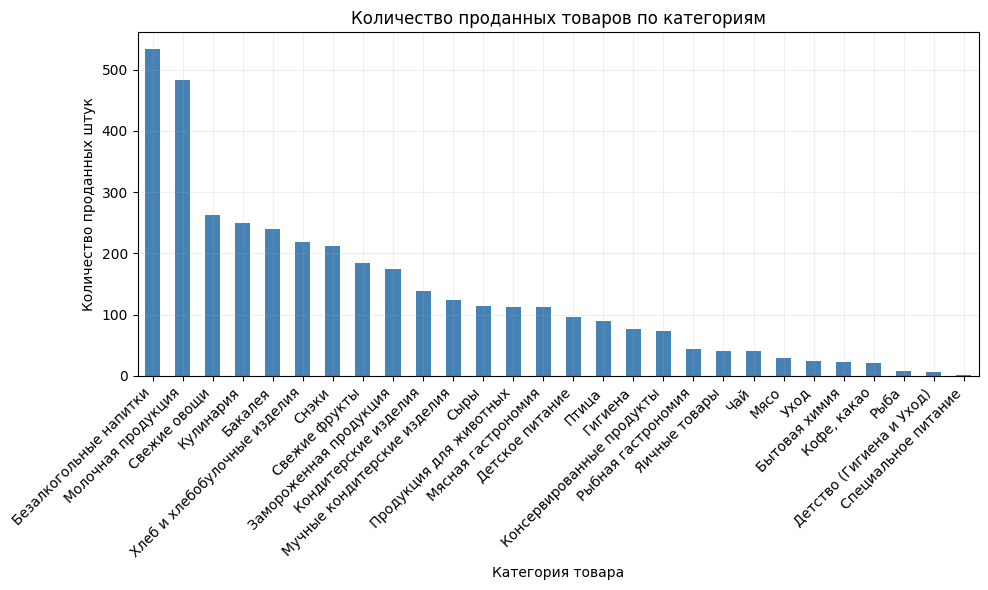

In [ ]:
plt.figure(figsize=(10, 6))
res1.plot(kind="bar", color="steelblue")
plt.title("Количество проданных товаров по категориям")
plt.xlabel("Категория товара")
plt.ylabel("Количество проданных штук")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 2 Task

Распределение продаж по подкатегориям
Оцените распределение количества проданных позиций в каждой товарной категории (level1) по подкатегориям (level2). Проиллюстрируйте свой результат расчетной таблицей.

In [121]:
df_merged = orders.merge(products, on="product_id", how="inner")

df2_1 = (
    df_merged.groupby(["level1", "level2"])["quantity"]
    .sum()
    .reset_index()
    .sort_values("quantity", ascending=False)
)
df2_1

,level1,level2,quantity
13,Безалкогольные напитки,Напитки,252
54,Кулинария,Готовые блюда,248
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
86,Снэки,Снэки соленые,180
12,Безалкогольные напитки,Воды питьевые,162
...,...,...,...
68,Мясная гастрономия,Субпродуктовые изделия,2
92,Уход,Средства по уходу за волосами,2
87,Специальное питание,Диетическое питание,2
17,Бытовая химия,Средства для сантехники,1


# 3 Task

Найти средний чек в заданную дату
Какой средний чек был 13.01.2022?

In [122]:
res = (
    orders[(orders["accepted_at"].dt.date == pd.Timestamp("2022-01-13").date())]
    .groupby("order_id")
    .apply(lambda x: (x["price"] * x["quantity"]).sum())
    .mean()
    .round(2)
)

res

np.float64(915.64)

# 4 Task

Доля промо в заданной категории
Когда товар продается по промо-акции, его базовая цена не совпадает с фактической ценой.

Вам необходимо:

Посчитать, какую долю от общих продаж категории Сыры занимают промо (в штуках)
Построить пайчарт, который это проиллюстрирует. На графике должны быть видны группы, соответствующие доли и понятные подписи к ним.

In [123]:
df_cheese = df_merged[df_merged["level1"] == "Сыры"].copy()

df_cheese["promo"] = df_cheese["price"] < df_cheese["regular_price"]

map = {True: "Promo", False: "Regular"}

df_cheese["promo"] = df_cheese["promo"].map(map)


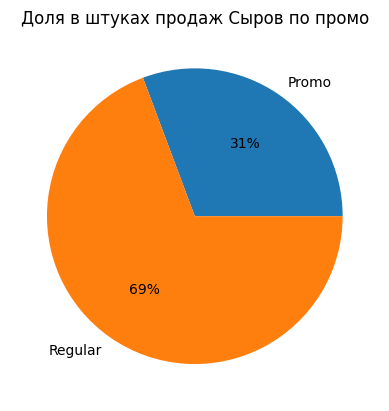

In [124]:
df_cheese_pie = df_cheese.groupby("promo")["quantity"].sum().reset_index()
df_cheese_pie
plt.pie(df_cheese_pie["quantity"], labels=df_cheese_pie["promo"], autopct="%.0f%%")
plt.title("Доля в штуках продаж Сыров по промо");

# 4 Task

Посчитать маржу по категориям
Нужно посчитать маржу:

В рублях
В %
Сделать это нужно по всем категориям level1 и отобразить с помощью 2 горизонтальных барчартов. Все подписи должны быть читаемыми и понятными.

In [125]:
def calculate_margain(x):
    d = {}
    d["margain_rur"] = sum((x["price"] - x["cost_price"]) * x["quantity"])
    d["margain_perc"] = d["margain_rur"] / sum(x["price"] * x["quantity"]) * 100
    return pd.Series(d, index=["margain_rur", "margain_perc"])

In [126]:
df4 = df_merged.copy()

df4_margain = df4.groupby("level1").apply(calculate_margain).reset_index()

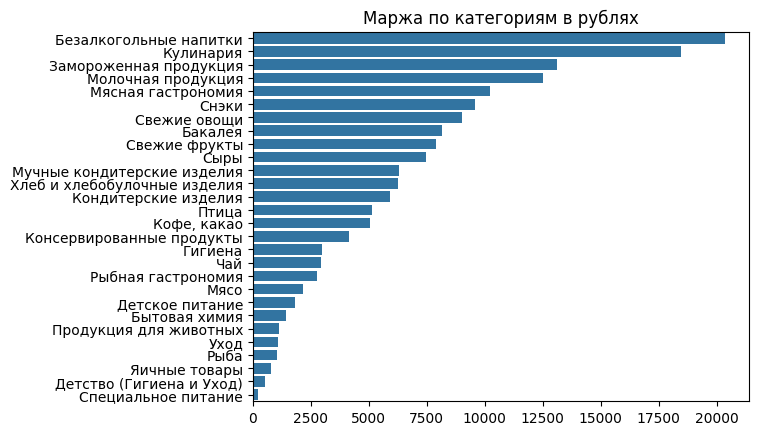

In [127]:
df4_rur_plot = df4_margain.sort_values("margain_rur", ascending=False)

sns.barplot(data=df4_rur_plot, x="margain_rur", y="level1")
plt.title("Маржа по категориям в рублях")
plt.xlabel("")
plt.ylabel("");

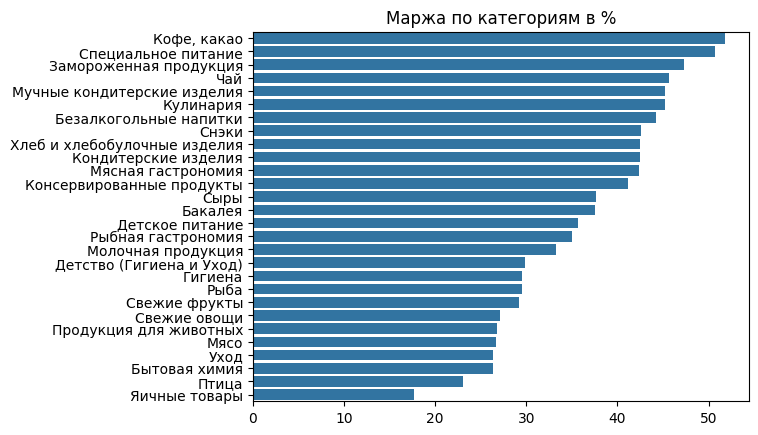

In [128]:
df4_perc_plot = df4_margain.sort_values("margain_perc", ascending=False)

sns.barplot(data=df4_perc_plot, x="margain_perc", y="level1")
plt.title("Маржа по категориям в %")
plt.xlabel("")
plt.ylabel("");

# 5 Task

ABC анализ
- Сделайте ABC-анализ продаж по количеству
- Сделайте ABC-анализ по сумме продаж
- Сделайте новый столбец, в котором будет итоговая группа на основании двух анализов. Например: A C.
* Важно: предлагаем провести ABC-анализ по подкатегориям, а не по отдельным товарам. Имеющихся у нас данных за небольшой период недостаточно для качественного анализа на уровне товаров. К тому же, количество товаров слишком велико, что может также исказить результаты. А ABC-анализ по подкатегориям даст более адекватную и интерпретируемую картину.

In [136]:
df_merged.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [137]:
tot_qty_sold = df_merged["quantity"].sum()

df_abc_qty = (
    df_merged.groupby("level2")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
df_abc_qty["quantity_perc"] = df_abc_qty["quantity"] / tot_qty_sold * 100
df_abc_qty["rolling_qty_perc"] = df_abc_qty["quantity_perc"].cumsum()
df_abc_qty["abc_qty"] = np.where(
    df_abc_qty["rolling_qty_perc"] <= 80,
    "A",
    np.where(df_abc_qty["rolling_qty_perc"] <= 95, "B", "C"),
)
df_abc_qty

,level2,quantity,quantity_perc,rolling_qty_perc,abc_qty
0,Напитки,252,6.752412,6.752412,A
1,Готовые блюда,248,6.645230,13.397642,A
2,Хлеб и хлебобулочные изделия,218,5.841372,19.239014,A
3,Снэки соленые,180,4.823151,24.062165,A
4,Воды питьевые,162,4.340836,28.403001,A
...,...,...,...,...,...
95,Пасты кондитерские,2,0.053591,99.839228,C
96,Средства по уходу за волосами,2,0.053591,99.892819,C
97,Субпродуктовые изделия,2,0.053591,99.946409,C
98,Средства для сантехники,1,0.026795,99.973205,C


In [139]:
df_merged["revenue"] = df_merged["price"] * df_merged["quantity"]
tot_revenue = df_merged["revenue"].sum()

df_abc_rev = (
    df_merged.groupby("level2")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
df_abc_rev["rev_perc"] = df_abc_rev["revenue"] / tot_revenue * 100
df_abc_rev["rolling_rev_perc"] = df_abc_rev["rev_perc"].cumsum()
df_abc_rev["abc_rev"] = np.where(
    df_abc_rev["rolling_rev_perc"] <= 80,
    "A",
    np.where(df_abc_rev["rolling_rev_perc"] <= 95, "B", "C"),
)
df_abc_rev

,level2,revenue,rev_perc,rolling_rev_perc,abc_rev
0,Готовые блюда,40356,9.032169,9.032169,A
1,Напитки,24123,5.399024,14.431192,A
2,Мясо птицы охлажденное,22349,5.001981,19.433173,A
3,"Тепличные овощи, грибы",18329,4.102255,23.535428,A
4,Снэки соленые,17293,3.870386,27.405814,A
...,...,...,...,...,...
95,Средства для сантехники,239,0.053491,99.839750,C
96,"Какао, горячий шоколад",238,0.053267,99.893018,C
97,Уход за одеждой и обувью,235,0.052596,99.945614,C
98,Первая помощь,168,0.037600,99.983214,C


In [142]:
df_abc = df_abc_qty.merge(df_abc_rev, on="level2", how="inner")
df_abc["abc_qty_rev"] = df_abc["abc_qty"].astype(str) + df_abc["abc_rev"].astype(str)
df_abc

,level2,quantity,quantity_perc,rolling_qty_perc,abc_qty,revenue,rev_perc,rolling_rev_perc,abc_rev,abc_qty_rev
0,Напитки,252,6.752412,6.752412,A,24123,5.399024,14.431192,A,AA
1,Готовые блюда,248,6.645230,13.397642,A,40356,9.032169,9.032169,A,AA
2,Хлеб и хлебобулочные изделия,218,5.841372,19.239014,A,14724,3.295412,44.574678,A,AA
3,Снэки соленые,180,4.823151,24.062165,A,17293,3.870386,27.405814,A,AA
4,Воды питьевые,162,4.340836,28.403001,A,9141,2.045868,58.805782,A,AA
...,...,...,...,...,...,...,...,...,...,...
95,Пасты кондитерские,2,0.053591,99.839228,C,518,0.115935,98.867062,C,CC
96,Средства по уходу за волосами,2,0.053591,99.892819,C,665,0.148835,97.952789,C,CC
97,Субпродуктовые изделия,2,0.053591,99.946409,C,324,0.072515,99.592662,C,CC
98,Средства для сантехники,1,0.026795,99.973205,C,239,0.053491,99.839750,C,CC
